# Análisis exploratorio de teléfonos

Validación y exploración de los datos originales. Este notebook no modifica los CSV ni entrena modelos.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import TARGET, TRAIN_PATH
from src.data.load_data import CargadorDatos

## 1. Carga de datos

In [2]:
cargador = CargadorDatos(TRAIN_PATH)
df = cargador.cargar()
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


## 2. Estructura y calidad

In [3]:
print(f'Dimensiones: {cargador.obtener_dimensiones()}')
print(f'Duplicados: {cargador.obtener_duplicados()}')
display(cargador.obtener_nulos().rename('nulos').to_frame())
df.info()

Dimensiones: (2000, 21)
Duplicados: 0


,nulos
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


## 3. Variable objetivo

,cantidad
price_range,
0,500
1,500
2,500
3,500


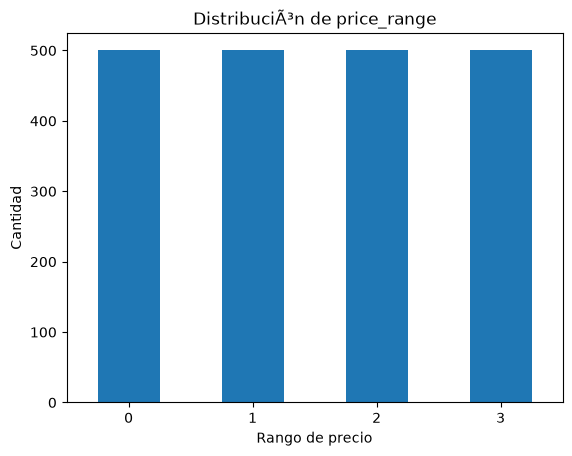

In [5]:
distribucion_objetivo = df[TARGET].value_counts().sort_index()
display(distribucion_objetivo.rename('cantidad').to_frame())
distribucion_objetivo.plot(kind='bar', title='Distribución de price_range')
plt.xlabel('Rango de precio')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.show()

## 4. Distribuciones de características seleccionadas

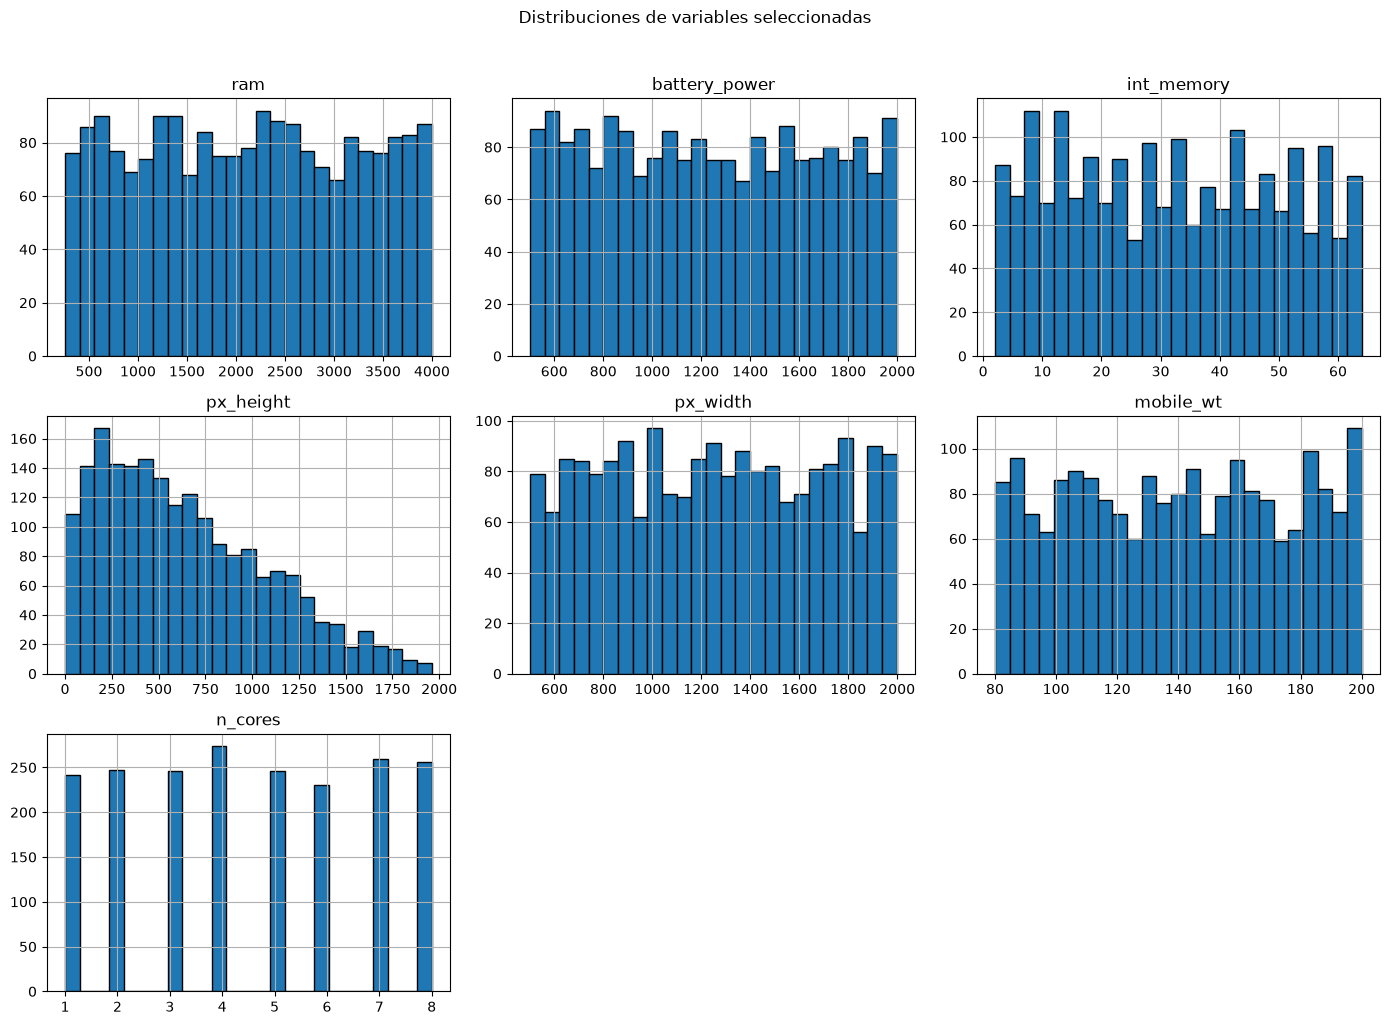

In [6]:
variables = [
    'ram', 'battery_power', 'int_memory', 'px_height',
    'px_width', 'mobile_wt', 'n_cores',
]
df[variables].hist(figsize=(14, 10), bins=25, edgecolor='black')
plt.suptitle('Distribuciones de variables seleccionadas', y=1.02)
plt.tight_layout()
plt.show()

## 5. Características según el rango de precio

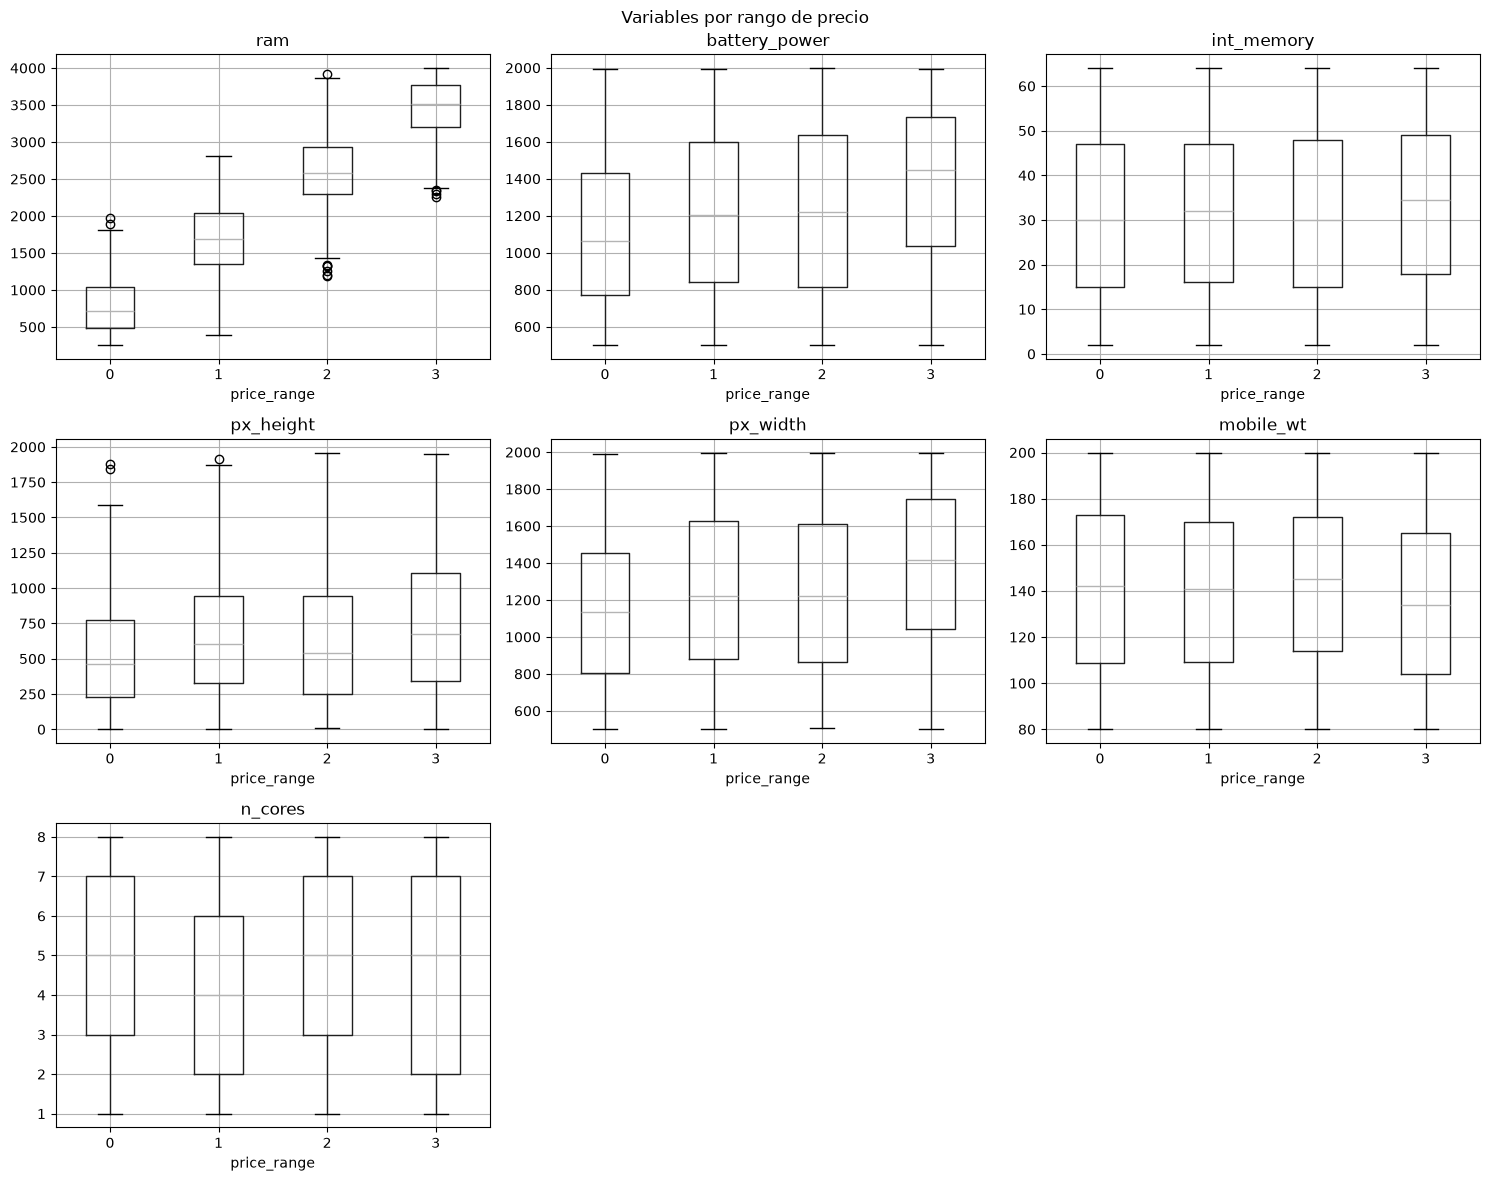

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for variable, eje in zip(variables, axes.flat):
    df.boxplot(column=variable, by=TARGET, ax=eje)
    eje.set_title(variable)
    eje.set_xlabel('price_range')
for eje in axes.flat[len(variables):]:
    eje.set_visible(False)
plt.suptitle('Variables por rango de precio')
plt.tight_layout()
plt.show()

## 6. Correlaciones

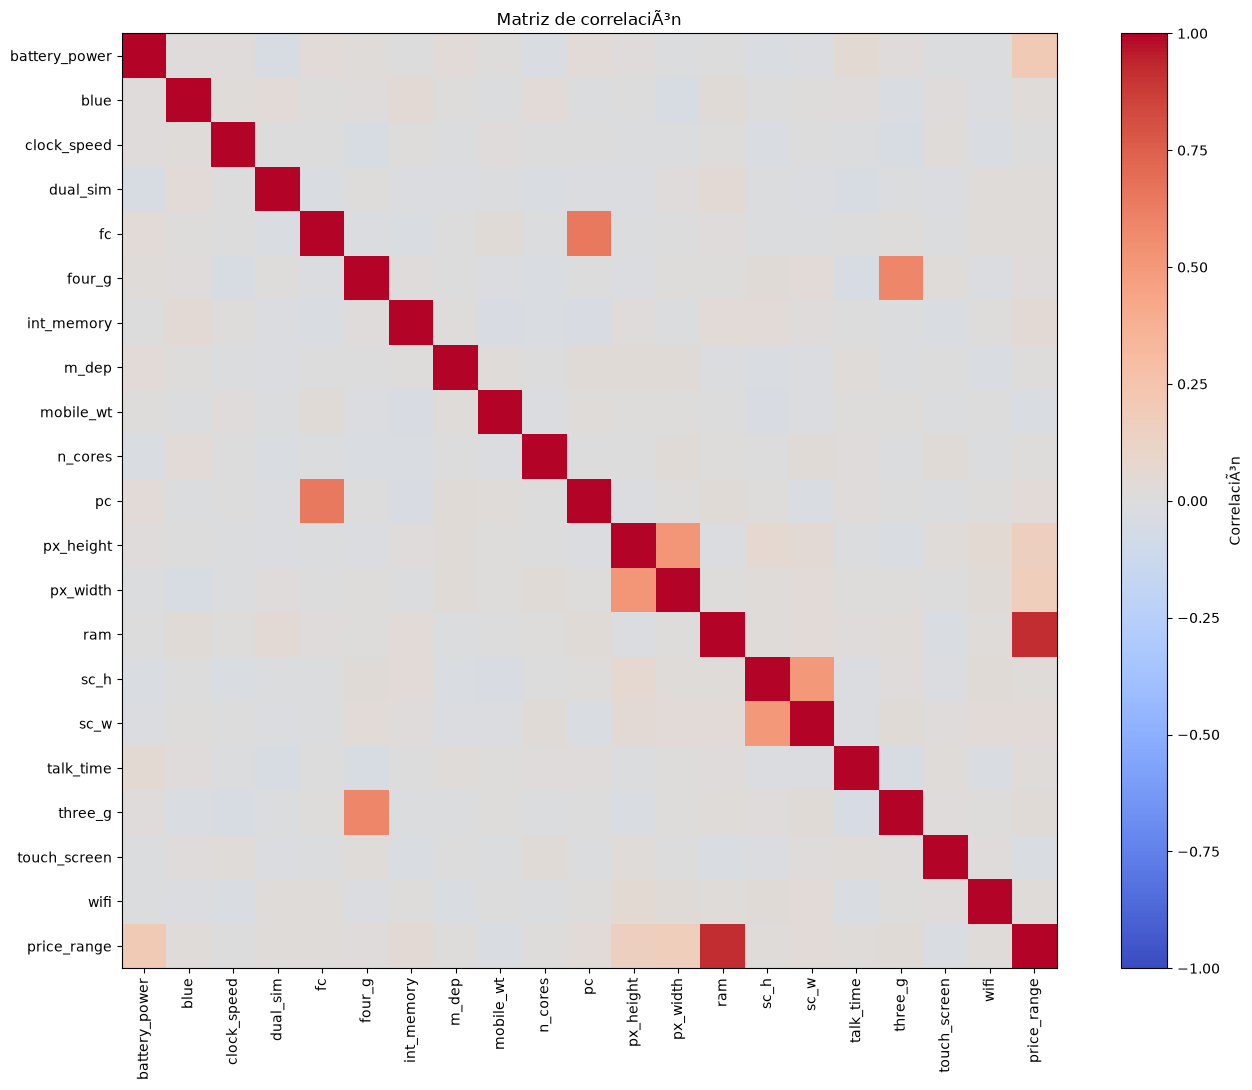

In [8]:
correlaciones = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(14, 11))
imagen = ax.imshow(correlaciones, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(correlaciones.columns)), correlaciones.columns, rotation=90)
ax.set_yticks(range(len(correlaciones.columns)), correlaciones.columns)
fig.colorbar(imagen, ax=ax, label='Correlación')
ax.set_title('Matriz de correlación')
plt.tight_layout()
plt.show()

In [9]:
correlacion_objetivo = (
    correlaciones[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)
correlacion_objetivo.rename('correlacion_con_price_range').to_frame()

,correlacion_con_price_range
ram,0.917046
battery_power,0.200723
px_width,0.165818
px_height,0.148858
int_memory,0.044435
sc_w,0.038711
pc,0.033599
touch_screen,-0.030411
mobile_wt,-0.030302
three_g,0.023611


## 7. Variables predictoras y objetivo

In [10]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f'X: {X.shape}')
print(f'y: {y.shape}')
print(f'Clases: {sorted(y.unique())}')

assert X.shape[1] == 20
assert set(y.unique()) == {0, 1, 2, 3}

X: (2000, 20)
y: (2000,)
Clases: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


## 8. Conclusiones

- El conjunto de entrenamiento tiene 2,000 observaciones y 20 variables predictoras.
- No presenta valores nulos ni filas duplicadas.
- Las cuatro clases de `price_range` están balanceadas.
- `ram` muestra la relación lineal más fuerte con el rango de precio.
- `battery_power`, `px_width` y `px_height` presentan relaciones menores, pero relevantes para el análisis posterior.